# BrushCue Example: Solarize

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/solarize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/solarize

In [ ]:
!pip install brushcue

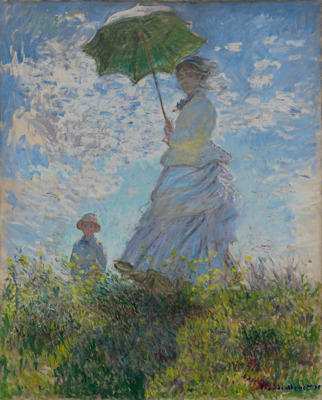

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
uniform_solarize_function_body_2 = brushcue.string_constant("let rgb = input.rgb;\nlet inverted = vec3<f32>(1.0 - rgb.r, 1.0 - rgb.g, 1.0 - rgb.b);\nlet solarized = select(rgb, inverted, rgb > vec3<f32>(threshold));\nreturn vec4<f32>(solarized, input.a);")
solarize_helpers_3 = brushcue.string_constant("")
solarize_input_profile_4 = brushcue.color_profile_s_r_g_b()
solarize_output_profile_5 = brushcue.color_profile_s_r_g_b()
solarize_needs_sample_capability_6 = brushcue.bool_constant(False)
solarize_inputs_7 = brushcue.dictionary_create()
solarize_threshold_key_8 = brushcue.string_constant("threshold")
solarize_threshold_input_9 = brushcue.float_add_to_dictionary(solarize_inputs_7, solarize_threshold_key_8, 0.5)
solarize_10 = brushcue.composition_custom_transformer_shader(input_image_1, uniform_solarize_function_body_2, solarize_helpers_3, solarize_input_profile_4, solarize_output_profile_5, solarize_threshold_input_9, solarize_needs_sample_capability_6)

ctx = brushcue.Context()
result = solarize_10.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
